In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Problem 1: Predicting House Prices

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/um-perez-alvaro/Data-Science-Practice/master/Data/kc_house_data.csv'
sales = pd.read_csv(url, index_col='id')
sales.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,,,,,,,,,,,,,,,,,,,,
7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


This dataset contains house sale prices for King County, which includes Seattle. 
It includes homes sold between May 2014 and May 2015.

There are 21 columns:

| Column | Description |
| :- | -: |
| id | Unique ID for each home sold |
| date | Date of the home sale |
| price | Price of each home sold |
| bedrooms | Number of bedrooms |
| bathrooms | Number of bathrooms, where .5 accounts for a room with a toilet but no shower |
| sqft_living | Square footage of the apartments interior living space |
| sqft_lot | Square footage of the land space |
| floors | Number of floors |
| waterfront | A dummy variable for whether the apartment was overlooking the waterfront or not |
| view | An index from 0 to 4 of how good the view of the property was |
| condition | An index from 1 to 5 on the condition of the apartment |
| grade | An index from 1 to 13, where 1-3 falls short of building construction and design, 7 has an average level of construction and design, and 11-13 have a high quality level of construction and design |
| sqft_above | The square footage of the interior housing space hat is above ground level |
| sqft_basement | The square footage of the interior housing space that is below ground level |
| yr_built | The year the house was initially built |
| yr_renovated | The year of the house's last renovation |
| zipcode | What zipcode area the house is in |
| lat | Latitude |
| long | Longitude |
| sqft_living15 | The square footage of interior housing living space for the nearest 15 neighbors |
| sqft_lot15 | The square footage of the land lots of the nearest 15 neighbors |

Your **goal** is to **train** a regression pipeline that predicts house prices, **tune** the pipeline hyperparameters, and **test** its performance.

In [3]:
X = sales.drop(['date','price'], axis=1)
y = sales.price

In [4]:


# train / test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y)



from sklearn.linear_model import LinearRegression

# initialize
linreg = LinearRegression()
# fit the model to the training data (learn the coefficients)
linreg.fit(X_train, y_train)



from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
pipe = Pipeline(steps=[
    ('scaler',MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=2,include_bias=False)),
    ('regressor', LinearRegression())
])
pipe

Pipeline(steps=[('scaler', MinMaxScaler()),
                ('poly_features', PolynomialFeatures(include_bias=False)),
                ('regressor', LinearRegression())])

In [5]:
# Ridge regularization
degree=2
alpha=0.5


from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error




pipe = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly_features', PolynomialFeatures(degree=degree,include_bias=False)),
    ('regressor', Ridge(alpha=alpha))
])

# fit the pipeline
pipe.fit(X_train,y_train)
#RMSE on train set
y_train_pred = pipe.predict(X_train)
rmse_train = mean_squared_error(y_train,y_train_pred)
#RMSE on test set
y_test_pred = pipe.predict(X_test)
rmse_test = mean_squared_error(y_test,y_test_pred)


# display RMSEs
print('RMSE on training set: '+str(np.round(rmse_train,2)))
print('RMSE on testing set: '+str(np.round(rmse_test,2)))

RMSE on training set: 23562559155.19
RMSE on testing set: 24116837998.94


**Plot** the observed prices against the predicted prices.

In [6]:
param_dict = {'poly_features__degree':list(range(1,2)),
             'regressor__alpha':list(np.linspace(0,1,10))}

In [7]:


# import GridSearch
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(pipe,
                    param_dict,
                    cv=5,
                    scoring='neg_mean_squared_error')

In [8]:


# fit the grid 
grid.fit(X_train,y_train)



/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=2.3973e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=6.46362e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/Users/vanmagnan/opt/anaconda3/lib/python3.8/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning: Ill-conditioned matrix (rcond=1.28298e-18): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', MinMaxScaler()),
                                       ('poly_features',
                                        PolynomialFeatures(include_bias=False)),
                                       ('regressor', Ridge(alpha=0.5))]),
             param_grid={'poly_features__degree': [1],
                         'regressor__alpha': [0.0, 0.1111111111111111,
                                              0.2222222222222222,
                                              0.3333333333333333,
                                              0.4444444444444444,
                                              0.5555555555555556,
                                              0.6666666666666666,
                                              0.7777777777777777,
                                              0.8888888888888888, 1.0]},
             scoring='neg_mean_squared_error')

In [11]:
best = grid.best_estimator_

In [12]:
y_train_pred = best.predict(X_train)
rmse_train = mean_squared_error(y_train,y_train_pred)
#RMSE on test set
y_test_pred = best.predict(X_test)
rmse_test = mean_squared_error(y_test,y_test_pred)

In [15]:
rmse_train


40570745030.737564

In [20]:
rmse_test/5000

8050332.864439316

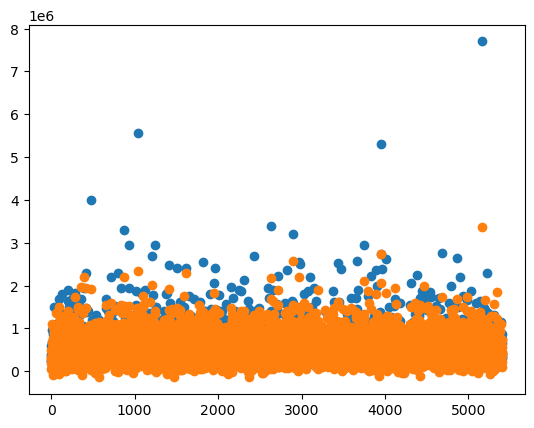

In [19]:
plt.scatter(range(len(X_test)),y_test)
plt.scatter(range(len(X_test)),y_test_pred)